# FACT Demo: Rhesus Quat

This notebook runs the FACT pipeline on the Rhesus macaque quaternion demo. 

Data required: `data\\Demo\\Rhesus\\Rhesus_quat.tif` (float32 values already pre-normalized to [0, 1])


In [1]:
import gc
import sys
import time
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import SimpleITK as sitk
import numpy as np
import torch

from IO.Read_tif import load_tiff
from ModelInference.SWInf import sliding_window_inference
from PostSlice.auto_sens import auto_sens_targetrad
from PostSlice.PostProcess_Pipeline import (
    Post_FACT_guided_backgroundremoving,
    Post_standard_spatial_consolidation,
    extract_roi_mean_traces,
)
from model.TS_Net_change import FACT_Net

ROI_SIZE = (128, 64, 64)
MAX_SW_BATCH_SIZE = 32
TARGET_RADIUS = 4.0


def _is_cuda_oom(error):
    return isinstance(error, torch.cuda.OutOfMemoryError) or (
        isinstance(error, RuntimeError) and "out of memory" in str(error).lower()
    )


def _release_cuda_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def get_auto_sw_batch_size(
    roi_size=ROI_SIZE,
    max_batch_size=MAX_SW_BATCH_SIZE,
    reserved_ratio=0.05,
    mem_per_patch_mb=705,
    device=None,
):
    del roi_size
    target_device = (
        torch.device(device)
        if device is not None
        else torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    )
    if target_device.type != "cuda" or not torch.cuda.is_available():
        return 1

    torch.cuda.empty_cache()
    free_bytes, total_bytes = torch.cuda.mem_get_info(target_device)
    safety_ratio = min(max(float(reserved_ratio), 0.0), 0.95)
    usable_bytes = max(0, int(float(free_bytes) * (1.0 - safety_ratio)))
    mem_per_patch = max(1, int(mem_per_patch_mb)) * 1024 * 1024
    estimated_batch = int(usable_bytes // mem_per_patch)
    batch_size = max(1, min(int(max_batch_size), estimated_batch))
    print(
        "Auto sw_batch_size: {} (free VRAM ~{:.1f}/{:.1f} GB; safety {:.0%})".format(
            batch_size,
            float(free_bytes) / 1024**3,
            float(total_bytes) / 1024**3,
            safety_ratio,
        )
    )
    return batch_size


fact_py311\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


### Load data


In [2]:
DATASET_NAME = "Rhesus_quat"
DATASET_SUBDIR = Path("Demo") / "Rhesus"
DATA_PATH = PROJECT_ROOT / "data" / DATASET_SUBDIR / f"{DATASET_NAME}.tif"
MODEL_PATH = PROJECT_ROOT / "ModelParams" / "FACT_Modelparams.pt"
data_path = str(DATA_PATH)

print(f"Dataset: {DATASET_NAME}")
print(f"TIFF: {DATA_PATH.relative_to(PROJECT_ROOT)}")


Dataset: Rhesus_quat
TIFF: data\Demo\Rhesus\Rhesus_quat.tif


In [ ]:
time_start = time.perf_counter()
input_img = np.asarray(load_tiff(str(DATA_PATH)), dtype=np.float32)
input_min = float(input_img.min())
input_max = float(input_img.max())
tolerance = 1e-6
if input_min < -tolerance or input_max > 1.0 + tolerance:
    raise ValueError(
        "Pre-normalized input must already lie in [0, 1]; "
        f"received range [{input_min}, {input_max}]."
    )
# Match GUI input_mode=pre_normalized_0_1: validate and pass through unchanged.
input_img = np.ascontiguousarray(input_img, dtype=np.float32)
print(f"Loaded pre-normalized video: shape={input_img.shape}, dtype={input_img.dtype}")
print(f"Input range after loading: [{input_min}, {input_max}]")
print(f"Read/load seconds: {time.perf_counter() - time_start:.2f}")


### Load FACT network


In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Inference device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


def _build_fact_model(target_device):
    fact_model = FACT_Net(
        img_size=ROI_SIZE,
        in_channels=1,
        out_channels=2,
        init_dim=3,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        use_checkpoint=True,
    ).to(target_device)
    weight = torch.load(str(MODEL_PATH), map_location="cpu", weights_only=False)
    fact_model.load_state_dict(weight["state_dict"])
    fact_model.eval()
    return fact_model


try:
    model = _build_fact_model(device)
except RuntimeError as exc:
    if device.type != "cuda" or not _is_cuda_oom(exc):
        raise
    del exc
    print("GPU cannot hold the FACT model; falling back to CPU.")
    _release_cuda_memory()
    device = torch.device("cpu")
    model = _build_fact_model(device)

print(f"Loaded model: {MODEL_PATH.relative_to(PROJECT_ROOT)}")


Inference device: cuda:0
GPU: NVIDIA GeForce RTX 3090


Loaded model: ModelParams\FACT_Modelparams.pt


### Network Inference


In [ ]:
time_start = time.perf_counter()
sw_batch_size = MAX_SW_BATCH_SIZE
print(f"Starting network inference with sw_batch_size={sw_batch_size} on {device}")


def _run_inference_once(batch_size):
    input_img_tensor = torch.from_numpy(input_img)
    test_inputs = input_img_tensor.unsqueeze(0).unsqueeze(1)
    with torch.no_grad():
        test_outputs = sliding_window_inference(
            test_inputs,
            ROI_SIZE,
            sw_batch_size=int(batch_size),
            predictor=model,
            overlap=[0.6, 0.2, 0.2],
            progress=True,
            mode="constant",
            device=torch.device("cpu"),
            sw_device=device,
        )
        diff = test_outputs[0, 1, :, :, :] - test_outputs[0, 0, :, :, :]
        diff_np = diff.detach().float().cpu().numpy()
        thresh = auto_sens_targetrad(diff_np, target_rad=TARGET_RADIUS)
        infer_mask3d_local = (diff_np > thresh).astype(np.uint8)
    del test_outputs, diff, diff_np, test_inputs, input_img_tensor
    return infer_mask3d_local, thresh


while True:
    try:
        infer_mask3d, thresh = _run_inference_once(sw_batch_size)
        break
    except RuntimeError as exc:
        if device.type != "cuda" or not _is_cuda_oom(exc):
            raise
        del exc
        _release_cuda_memory()
        if sw_batch_size > 1:
            previous_batch_size = sw_batch_size
            next_batch_size = max(1, previous_batch_size // 2)
            if previous_batch_size == MAX_SW_BATCH_SIZE:
                estimated_batch_size = get_auto_sw_batch_size(
                    roi_size=ROI_SIZE,
                    max_batch_size=MAX_SW_BATCH_SIZE,
                    reserved_ratio=0.05,
                    mem_per_patch_mb=705,
                    device=device,
                )
                next_batch_size = min(next_batch_size, estimated_batch_size)
            sw_batch_size = next_batch_size
            print(
                f"CUDA OOM at sw_batch_size={previous_batch_size}; "
                f"retrying with sw_batch_size={sw_batch_size}."
            )
            continue

        print("CUDA OOM at sw_batch_size=1; falling back to CPU inference.")
        model = model.to(torch.device("cpu"))
        device = torch.device("cpu")
        _release_cuda_memory()
        sw_batch_size = 1
        infer_mask3d, thresh = _run_inference_once(sw_batch_size)
        break

if device.type == "cuda":
    torch.cuda.empty_cache()
gc.collect()
print(f"Network inference complete: infer_mask3d={infer_mask3d.shape}")
print(f"auto_sens threshold used: {thresh}")
print(f"Inference sw_batch_size used: {sw_batch_size}")
print(f"Inference device used: {device}")


### Calculate STD


In [6]:
T, H, W = (int(value) for value in infer_mask3d.shape)
mask_shape_2d = (H, W)
infer_mask3d = np.asarray(infer_mask3d, dtype=np.uint8)

std_raw = np.std(input_img, axis=0, dtype=np.float64)
std_img = ((std_raw - std_raw.min()) / (std_raw.max() - std_raw.min()) * 255.0).astype(
    np.float32
)
del std_raw
gc.collect()
print(f"Postprocess mask shape: {mask_shape_2d}; frames: {T}")


Postprocess mask shape: (256, 256); frames: 7001


## Post-processing


In [7]:
POST_PARAMS = {
    "max_area": 678,
    "min_area": 20,
    "thresh_com": 5.0,
    "thresh_com_refine": 8.0,
    "thresh_iou": 0.5,
    "thresh_acti": 2,
    "thresh_refine": 0.3,
    "thresh_consume": 0.75,
    "num_workers": 8,
}

post_start = time.perf_counter()
masks_final, _timestamps_final = Post_standard_spatial_consolidation(
    infer_mask3d,
    mask_shape_2d=mask_shape_2d,
    min_area=POST_PARAMS["min_area"],
    max_area=POST_PARAMS["max_area"],
    thresh_com=POST_PARAMS["thresh_com"],
    thresh_com_refine=POST_PARAMS["thresh_com_refine"],
    thresh_refine=POST_PARAMS["thresh_refine"],
    thresh_iou=POST_PARAMS["thresh_iou"],
    thresh_consume=POST_PARAMS["thresh_consume"],
    thresh_acti=POST_PARAMS["thresh_acti"],
    num_workers=POST_PARAMS["num_workers"],
)
masks_final = (masks_final.tocsr() > 0).astype(np.int64)
print(f"Spatial postprocess complete: masks={masks_final.shape[0]}")
print(f"Postprocess seconds: {time.perf_counter() - post_start:.2f}")


Finding mask pairs
Calculating transfered masks


Spatial postprocess complete: masks=48
Postprocess seconds: 4.98


In [8]:
masks_for_trace = (masks_final.tocsr() > 0).astype(np.int64)
traces_roi_init = extract_roi_mean_traces(masks_for_trace, input_img)
sources = np.zeros((masks_for_trace.shape[0],), dtype=bool)

background_result = Post_FACT_guided_backgroundremoving(
    masks_for_trace,
    traces_roi_init,
    sources,
    infer_mask3d=infer_mask3d,
    input_img=input_img,
    mask_shape_2d=mask_shape_2d,
    run_overlap_demix=False,
    binarize_final=True,
)
masks_final = (background_result["masks_final"].tocsr() > 0).astype(np.int64)
traces_roi = np.asarray(background_result["traces_cell"], dtype=np.float32)
traces_background = np.asarray(background_result["traces_bg"], dtype=np.float32)
traces_final = np.asarray(background_result["traces_final"], dtype=np.float32)
sources = np.asarray(background_result["sources"], dtype=bool).reshape(-1)
alpha_nnls = np.asarray(background_result["alpha_nnls"], dtype=np.float32).reshape(-1)
del masks_for_trace, traces_roi_init, background_result
gc.collect()
print(f"FACT-guided background removal complete: masks={masks_final.shape[0]}")


FACT-guided background removal complete: masks=48


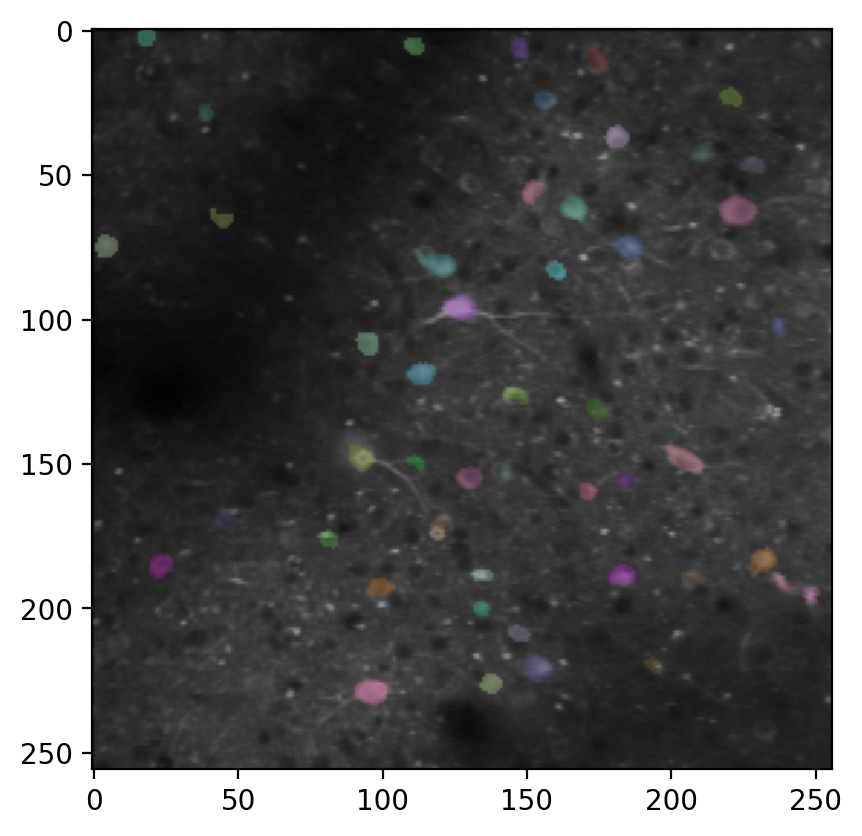

In [9]:
import matplotlib.pyplot as plt
from PostSlice.UI.Drawmap import draw_mask_colormap
from UI.Combine import combine_masks

showmap = draw_mask_colormap(masks_final, mask_shape_2d)
show_combined = combine_masks(
    showmap,
    std_img,
    alpha=0.3,
    brightness_factor=0.6,
    mask_threshold=1,
)
plt.figure(dpi=200)
plt.imshow(show_combined)
plt.show()


## Interactive exhibition of masks and traces


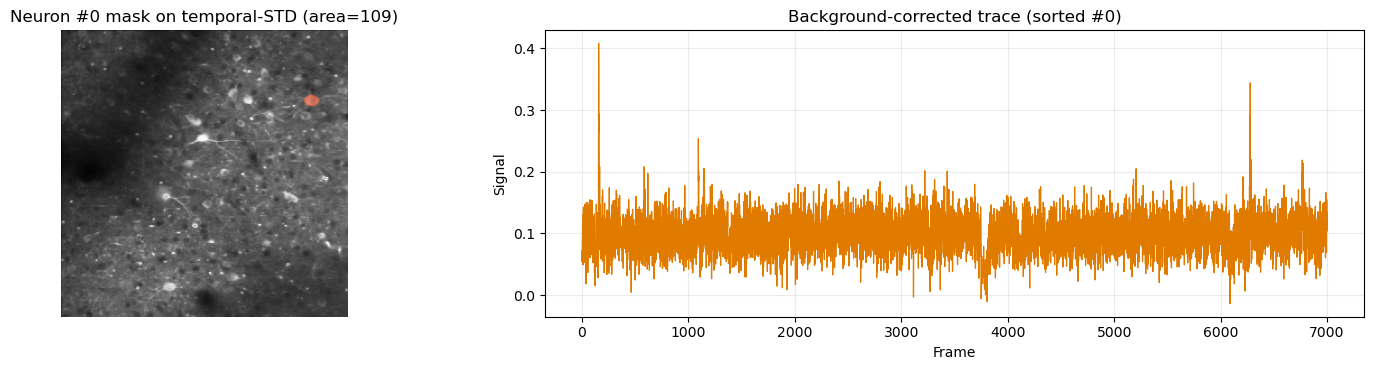

In [10]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


def _single_mask_flat(mask_array, row_index):
    row = mask_array.getrow(int(row_index))
    return np.asarray(row.toarray()).ravel()


def _warm_color(row_index):
    hue = (0.035 + 0.11 * ((int(row_index) * 37) % 101) / 100.0) % 1.0
    return (mcolors.hsv_to_rgb((hue, 0.90, 1.0)) * 255.0).astype(np.float32)


def _overlay_for_row(row_index):
    mask = _single_mask_flat(masks_final, row_index).reshape(mask_shape_2d) > 0
    gray = np.clip(std_img, 0.0, 255.0).astype(np.float32)
    overlay = np.repeat(gray[..., None], 3, axis=2)
    color = _warm_color(row_index)
    overlay[mask] = 0.5 * overlay[mask] + 0.5 * color
    return np.clip(overlay, 0, 255).astype(np.uint8), mask


mask_areas = np.asarray(masks_final.getnnz(axis=1)).ravel()
sorted_neuron_indices = np.argsort(mask_areas)[::-1]
neuron_count = int(masks_final.shape[0])


def show_single_neuron(sorted_idx):
    sorted_idx = int(sorted_idx)
    neuron_idx = int(sorted_neuron_indices[sorted_idx])
    overlay, mask = _overlay_for_row(neuron_idx)
    trace = np.asarray(traces_final[neuron_idx]).ravel()
    fig, axes = plt.subplots(1, 2, figsize=(16, 3.8))
    axes[0].imshow(overlay)
    axes[0].set_title(
        f"Neuron #{neuron_idx} mask on temporal-STD (area={int(mask_areas[neuron_idx])})"
    )
    axes[0].axis("off")
    axes[1].plot(trace, lw=0.9, color="#e07b00")
    axes[1].set_title(f"Background-corrected trace (sorted #{sorted_idx})")
    axes[1].set_xlabel("Frame")
    axes[1].set_ylabel("Signal")
    axes[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


if neuron_count == 0:
    print("No masks were produced; interactive viewer is unavailable.")
else:
    show_single_neuron(0)
    neuron_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=neuron_count - 1,
        step=1,
        description="Sorted#",
        continuous_update=False,
    )
    viewer_output = widgets.interactive_output(
        show_single_neuron, {"sorted_idx": neuron_slider}
    )
    display(widgets.VBox([neuron_slider, viewer_output]))


#### Save masks (Optional)


In [11]:
data_dir = DATA_PATH.parent
data_name = DATA_PATH.stem
print(f'data dir is "{data_dir}", data name is "{data_name}"')
infer_dir = data_dir
save_filepth = str(infer_dir / data_name)


data dir is "FACT-Code-Release\data\Demo\Rhesus", data name is "Rhesus_quat"


In [12]:
try:
    from IO.SaveROI import save_roi_imagej
except ModuleNotFoundError:
    import cv2
    from roifile import ImagejRoi, ROI_TYPE, roiwrite

    def save_roi_imagej(masks, maskshape_2d, save_path):
        list_rois = []
        for single_mask_arr in masks:
            single_mask_mat = single_mask_arr.toarray().reshape(maskshape_2d)
            single_mask_mat = single_mask_mat.astype(np.uint8)
            contours, _ = cv2.findContours(
                single_mask_mat, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
            )
            boundary_points = []
            for contour in contours:
                for point in contour:
                    x, y = point[0]
                    boundary_points.append([x, y])
            if not boundary_points:
                continue
            single_roi = ImagejRoi.frompoints(np.asarray(boundary_points))
            single_roi.roitype = ROI_TYPE.FREEHAND
            list_rois.append(single_roi)
        roiwrite(save_path, list_rois)

savepth_roi = save_filepth + "_FACTmaskROI.zip"
save_roi_imagej(masks_final, mask_shape_2d, savepth_roi)


In [13]:
from IO.Save_mat import savemask_mat

savemask_mat(
    masks=masks_final,
    maskshape_2d=mask_shape_2d,
    save_pth=save_filepth,
    annotate="FACTmasks",
)
